**"Our dataset is the Space Mission data, covering 4,324 rocket launches from 1957 to 2020. basically the entire history of orbital rocket launches. It includes details like the organisation that launched it (SpaceX, NASA, Roscosmos, etc.), the location, the rocket name, the launch date, whether the rocket is active or retired, the launch price, and whether the mission succeeded or failed. We cleaned the data and estimated missing prices, and today we're focusing mainly on what drives mission success and rocket status."**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import textwrap

sdata = pd.read_csv(r"C:\Users\sanke\Downloads\space_mission_data.csv",index_col=0)
sdata

,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50,Success
1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65,Success
4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145,Success
...,...,...,...,...,...,...,...,...
4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [2]:
sdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4324 entries, 0 to 4323
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      4324 non-null   int64 
 1   Organisation    4324 non-null   object
 2   Location        4324 non-null   object
 3   Date            4324 non-null   object
 4   Detail          4324 non-null   object
 5   Rocket_Status   4324 non-null   object
 6   Price           964 non-null    object
 7   Mission_Status  4324 non-null   object
dtypes: int64(1), object(7)
memory usage: 304.0+ KB


In [3]:
sdata.Organisation.value_counts()

Organisation
RVSN USSR           1777
Arianespace          279
CASC                 251
General Dynamics     251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
ISA                   13
Rocket Lab            13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
MITT                   7
JAXA                   7
Land Launch            7
UT                     5
KCST                   5
CASIC                  5
Exos                   4
CECLES                 4
Arm??e de l'

In [4]:
sdata.Detail.value_counts()

Detail
Cosmos-3MRB (65MRB) | BOR-5 Shuttle    6
Lambda-IV S | Osumi                    5
Titan IV(402)B | DSP                   5
Titan IIID | KH-11                     5
Proton K/Block D | Zond                4
                                      ..
Ariane 44P | Intelsat 709              1
Ariane 5 G | Cluster                   1
Delta II 7925 | Galaxy 9               1
Space Shuttle Endeavour | STS-77       1
Sputnik 8K71PS | Sputnik-1             1
Name: count, Length: 4278, dtype: int64

In [5]:
sdata.Mission_Status.value_counts()

Mission_Status
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

#### Mission_Status

**Success** — Launch vehicle performed flawlessly, delivering payload successfully.

**Failure** — Launch failed entirely, destroying payload completely.

**Partial Failure** — Mission partially succeeded, reaching wrong orbit.

**Prelaunch Failure** — Rocket exploded or failed before liftoff.

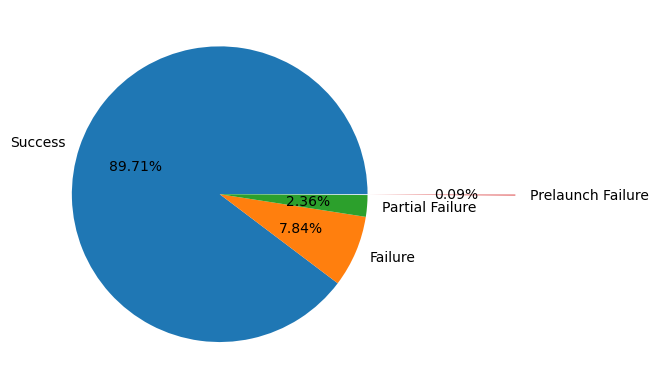

In [6]:
exp = [0,0,0,1]
sdata.Mission_Status.value_counts().plot(kind="pie",explode=exp,autopct="%.2f%%");
plt.ylabel(" ");

#### Inferences:
Approximately 90% of all missions were successful.
Around 8% were outright failures, and approx 2% were partial failures.
This one chart makes the point: space missions have a very high success rate overall, so failures are the exception, not the norm.

Year contains the actual year extracted from the Date column. For example, a mission on 2019-04-11 has Year = 2019.

Decade is not the last two digits of the year. It represents the starting year of that decade.

So:

1957 → Decade = 1950
1968 → Decade = 1960
1975 → Decade = 1970
1989 → Decade = 1980
1994 → Decade = 1990
2007 → Decade = 2000
2019 → Decade = 2010
2020 → Decade = 2020

So 2019 → 2010 means the 2010s (2010–2019). We used this format because it makes grouping and sorting by decade easier in Python.

In [7]:
smd = pd.read_csv(r"C:\Users\sanke\Downloads\Space_Mission_Data_Final.csv",index_col=0)
smd

,Organisation,Country,ISO Code,Vehicle_Name,Launch_date,Launch_Month,Launch_Year,Rocket_Status,Price,Mission_Status,Decade
0,SpaceX,USA,USA,Falcon 9 Block 5,07-08-2020,Aug,2020,StatusActive,50.00,Success,2020
1,CASC,China,CHN,Long March 2D,06-08-2020,Aug,2020,StatusActive,29.75,Success,2020
2,SpaceX,USA,USA,Starship Prototype,04-08-2020,Aug,2020,StatusActive,50.00,Success,2020
3,Roscosmos,Kazakhstan,KAZ,Proton-M/Briz-M,30-07-2020,Jul,2020,StatusActive,65.00,Success,2020
4,ULA,USA,USA,Atlas V 541,30-07-2020,Jul,2020,StatusActive,145.00,Success,2020
...,...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,USA,USA,Vanguard,05-02-1958,Feb,1958,StatusRetired,62.00,Failure,1950
4320,AMBA,USA,USA,Juno I,01-02-1958,Feb,1958,StatusRetired,62.00,Success,1950
4321,US Navy,USA,USA,Vanguard,06-12-1957,Dec,1957,StatusRetired,62.00,Failure,1950
4322,RVSN USSR,Kazakhstan,KAZ,Sputnik 8K71PS,03-11-1957,Nov,1957,StatusRetired,5000.00,Success,1950


In [8]:
smd.Rocket_Status.value_counts()

Rocket_Status
StatusRetired    3534
StatusActive      790
Name: count, dtype: int64

### 1. How has success rate changed over time?

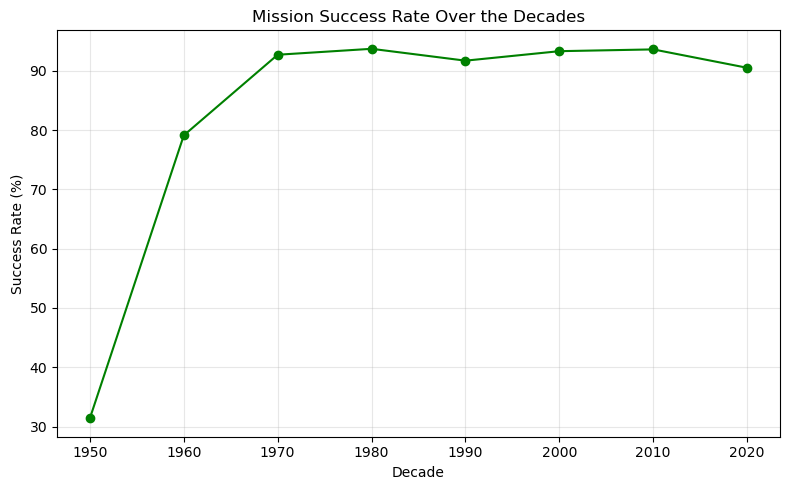

In [9]:
# Finding Total launches per decade
total_by_decade = smd.groupby('Decade').size()

# Successful launches per decade
success_by_decade = smd[smd['Mission_Status'] == 'Success'].groupby('Decade').size()

# success rate in % per decade
success_rate_decade = (success_by_decade / total_by_decade * 100).round(1)

# Creating line chart as we have time(decades) variable on x axis
success_rate_decade.plot(kind='line', marker='o', color='green', figsize=(8,5))
plt.title('Mission Success Rate Over the Decades')
plt.xlabel('Decade')
plt.ylabel('Success Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout() #automatically adjusts spacing so titles, labels, and legends don't overlap or get cut off — it's purely cosmetic and doesn't affect your actual data or chart values.
plt.show()

#### Inferences:

1. Success rate jumped from just ~30% in the 1950s to 80% in the 1960s.
2. From the 1970s onward, success has stayed consistently above 90%, peaking at 93.7% in the 1980s which is 3x of success rate from the 1950s
3. The 2020s are running at 90% so far space launches have gotten dramatically safer over 70 years.


The 1950s was the very start of the Space Race, The 1950s were the experimental,  the US and USSR were rushing to be first, often launching untested, prototype rockets with little prior flight data. There was no "playbook" yet engineers were learning through trial and error, often in real time so failures were common and expected at that stage. 


by the 1970s–80s, better computers, simulations, and precision manufacturing reduced the guesswork that caused many 1950s failures. Better systems engineering and testing culture after some very public early failures (and disasters like Apollo 1 in 1967), space programs adopted much stricter testing, quality control, and redundancy checks before launch. as rockets became standardized and were flown repeatedly, reliability naturally climbed, and it's stayed consistently above 90% ever since.

### 2. Which country has the highest launch success rate?

In [10]:
#Counting Number of launches per each country
smd['Country'].value_counts().head(10)

Country
Russia           1395
USA              1345
Kazakhstan        701
France            303
China             269
Japan             126
India              76
Pacific Ocean      36
Iran               14
New Zealand        13
Name: count, dtype: int64

In [11]:
#Find the 10 countries with ISO Code having the most number launches
top_countries = smd['Country'].value_counts().head(10).index
top_countries

#Keep only rows from those countries
country_df = smd[smd['Country'].isin(top_countries)]

#Calculate % of "Success" missions for each country
success_rate_country = (country_df[country_df['Mission_Status'] == 'Success'].groupby('Country').size()/ country_df.groupby('Country').size() * 100).sort_values(ascending=False)
success_rate_country

Country
France           94.059406
Russia           93.405018
Pacific Ocean    91.666667
China            90.706320
Japan            89.682540
USA              88.178439
Kazakhstan       86.733238
New Zealand      84.615385
India            82.894737
Iran             35.714286
dtype: float64

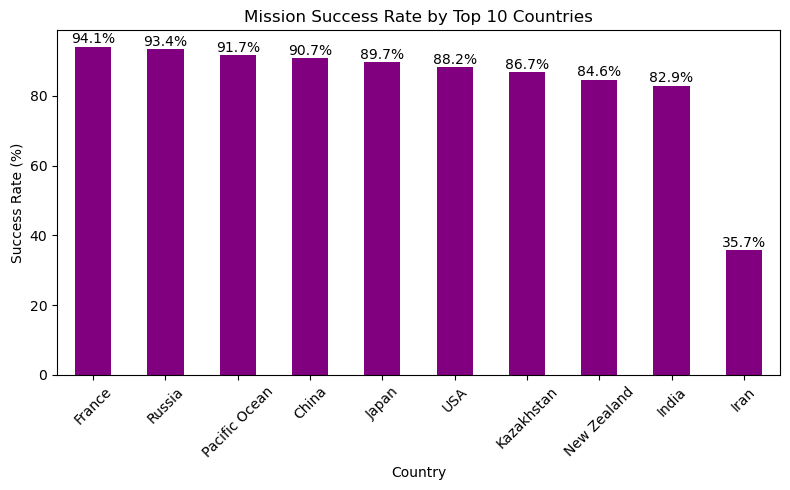

In [12]:
import matplotlib.pyplot as plt

# Step 1: Find the top 10 countries with the most launches
top_countries = smd['Country'].value_counts().head(10).index

# Step 2: Keep only rows from those countries
country_df = smd[smd['Country'].isin(top_countries)]

# Step 3: Calculate success rate % for each country
success_rate_country = (country_df[country_df['Mission_Status'] == 'Success']
                         .groupby('Country').size()
                         / country_df.groupby('Country').size() * 100).sort_values(ascending=False)

# Step 4: Plot the bar chart
ax = success_rate_country.plot(kind='bar', color='purple', figsize=(8,5))
plt.title('Mission Success Rate by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45)

# Step 5: Add % label on top of each bar
for i, value in enumerate(success_rate_country):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Inferences:

1. France (FRA) has the highest success rate at 94% across 303 launches.
2. Kazakhstan (KAZ) has the lowest at 86%, despite hosting 701 launches (mostly Soviet/Russian launch sites).
3. Russia (RUS) leads in total launches (1,398) and still holds a strong around 93% success rate.

"India's overall success rate looks lower mainly because of a rough start decades ago and a much smaller total number of launches but its recent success rate (93.6% in the 2010s) is just as strong as any major space program today."

### 3. which oragniztion lunched most mission?

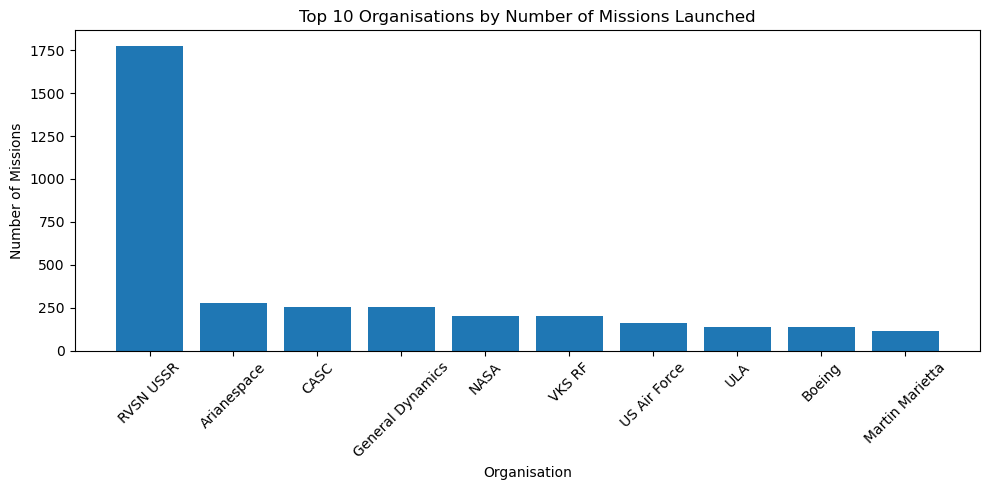

In [13]:
top10 = smd['Organisation'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10.index, top10.values)

plt.xlabel("Organisation")
plt.ylabel("Number of Missions")
plt.title("Top 10 Organisations by Number of Missions Launched")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inference:
1. RVSN USSR launched the highest number of missions, with approximately 1,775.
2. Which around 6.5 time more than Arianespace.
3. Martin Marietta has the lowest number among the top 10, with around 110 missions.
4. Overall, RVSN USSR clearly dominates the dataset, while the remaining organisations have much lower mission counts.

### Q4 Which cities recorded the highest number of  space mission

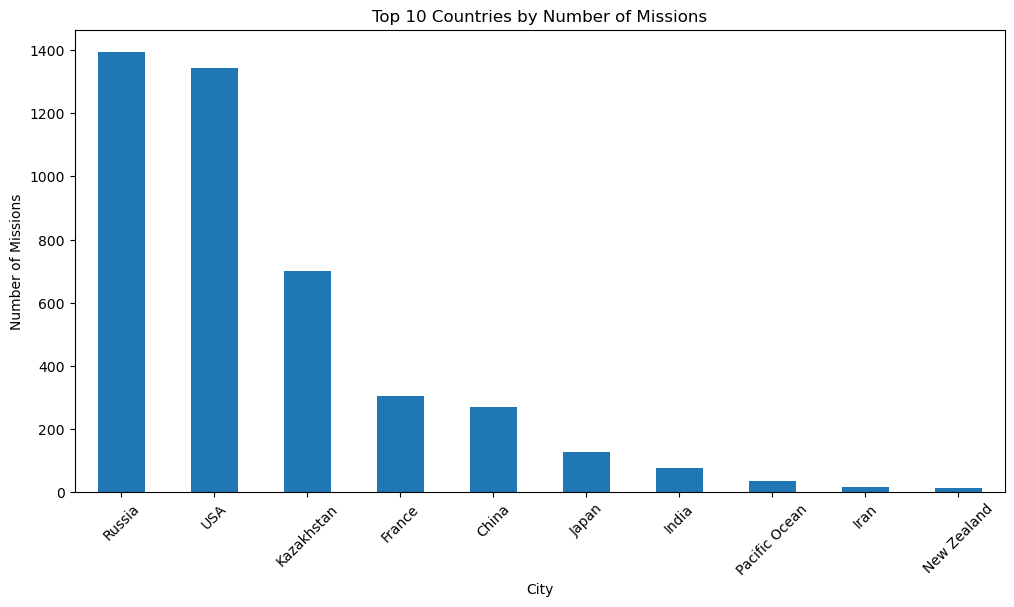

In [14]:
city_missions = smd["Country"].value_counts()

city_missions = city_missions.head(10)

plt.figure(figsize=(12, 6))
city_missions.plot(kind="bar")

plt.title("Top 10 Countries by Number of Missions")
plt.xlabel("City")
plt.ylabel("Number of Missions")
plt.xticks(rotation=45)
plt.show()

### Inference:
1. Russia recorded the highest numbers of space with approxmataly 1394 manking it the leading location in the database.
2. USA is Second with around 1340 missions very close to Russia.
3. New Zealand has the lowest mission among the top 10 with only around 10 missions.

### Q5. which oragniztion lunched most mission?

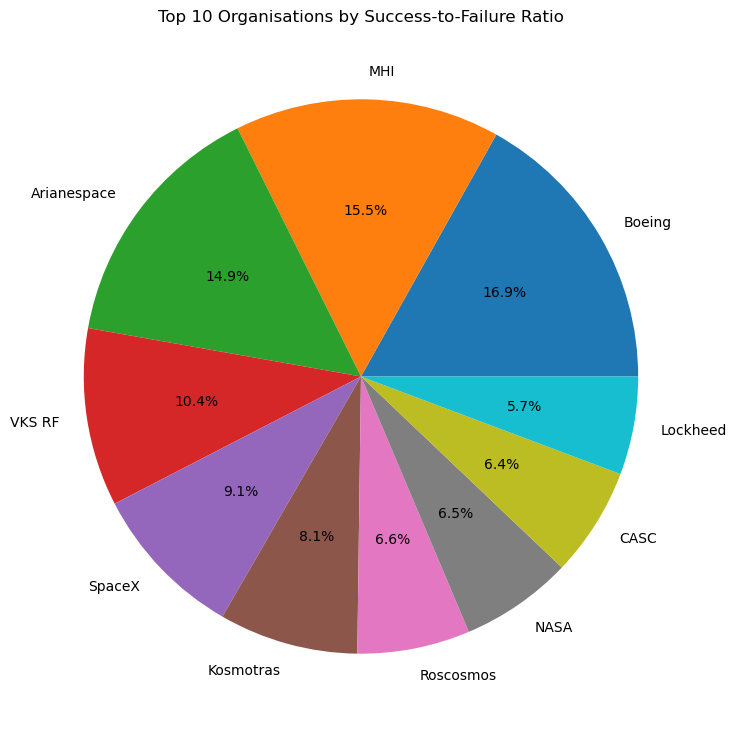

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Success and Failure count by Organisation
result = pd.crosstab(smd["Organisation"], smd["Mission_Status"])

# Failure = 0 wali organisations remove
result = result[result["Failure"] > 0]

# Success-to-Failure ratio
result["Ratio"] = result["Success"] / result["Failure"]

# Top 10 organisations by ratio
top10 = result.sort_values("Ratio", ascending=False).head(10)

# Pie Chart
plt.figure(figsize=(9, 9))

plt.pie(
    top10["Ratio"],
    labels=top10.index,
    autopct="%1.1f%%",
    
)

plt.title("Top 10 Organisations by Success-to-Failure Ratio")

plt.show()

### Inference:
1. RVSN USSR launched the highest number of missions, with approximately 1,775.
2. Which around 6.5 time more than Arianespace.
3. Martin Marietta has the lowest number among the top 10, with around 110 missions.
4. Overall, RVSN USSR clearly dominates the dataset, while the remaining organisations have much lower mission counts.

### Q6) Identify the top 10 most frequently launched vehicles and compare their launch frequencies.

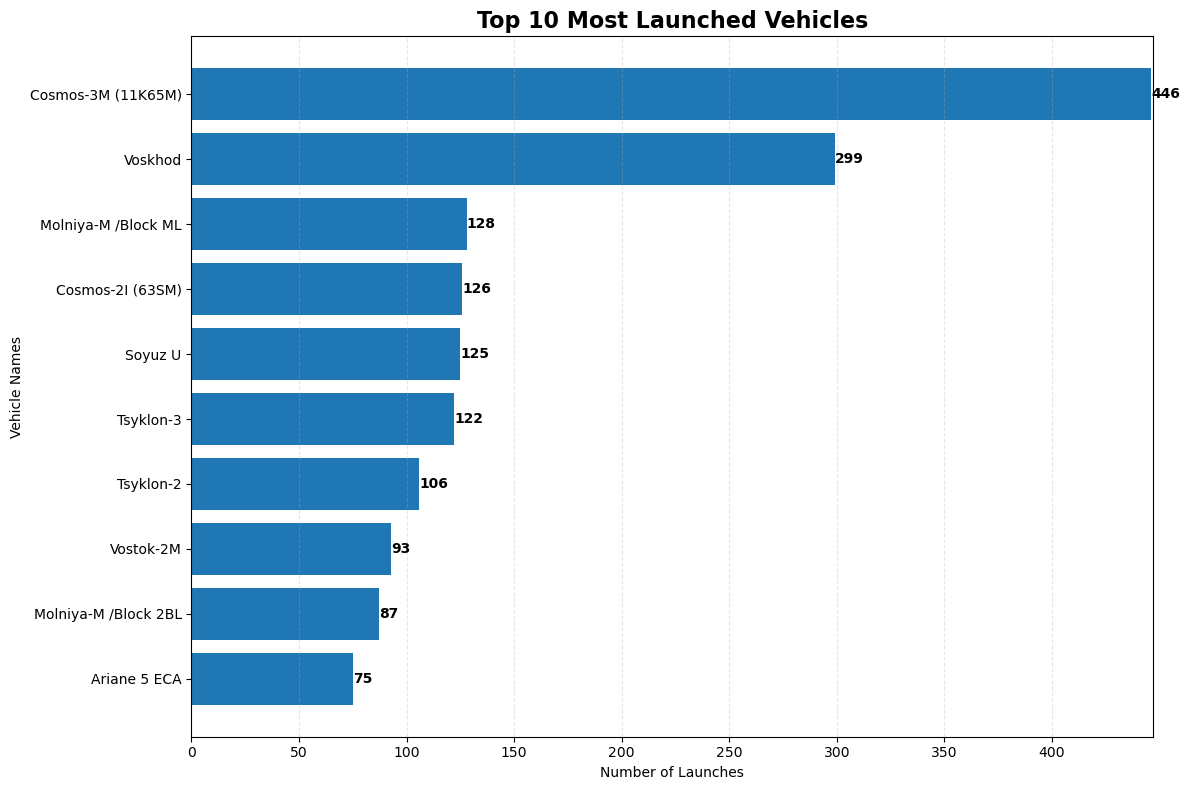

In [17]:
top10 = smd['Vehicle_Name'].value_counts().head(10)
top10 = top10.sort_values(ascending=True)

labels = [textwrap.fill(str(x), 35) for x in top10.index]

plt.figure(figsize=(12, 8))


bars = plt.barh(labels, top10.values)

plt.title(
    'Top 10 Most Launched Vehicles',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Launches')
plt.ylabel('Vehicle Names')

for bar, value in zip(bars, top10.values):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        str(value),
        va='center',
        fontweight='bold'
    )

plt.xlim(0, top10.max() + 1)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Inferences
1. Cosmos-3M (11K65M) was the most frequently launched vehicle, with 446 launches, followed by Voskhod with 299 launches.
2. Cosmos-3M and Voskhod were used considerably more than the other vehicles, indicating that these rocket models were frequently selected for missions in the dataset.
3. Ariane 5 ECA had the lowest number of launches among the top 10, with 75 launches, while the remaining vehicles had between 87 and 128 launches, showing a clear difference in launch frequency.

#### Q7) Find the Success Rate of the 15 Most-Used Rocket Models

In [18]:
# Find the 15 most-used rocket models
top10 = (
    smd.groupby('Vehicle_Name')
    .agg(
        Total_Launches=('Mission_Status', 'size'),
        Successful_Launches=('Mission_Status',
                             lambda x: (x.str.strip().str.lower() == 'success').sum())
    )
    .sort_values('Total_Launches', ascending=False)
    .head(10)
)

# Calculate Success Rate
top10['Success_Rate'] = (
    top10['Successful_Launches'] / top10['Total_Launches']
) * 100

# Reset index
top10 = top10.reset_index()
#Display the calculated data
top10

,Vehicle_Name,Total_Launches,Successful_Launches,Success_Rate
0,Cosmos-3M (11K65M),446,419,93.946188
1,Voskhod,299,283,94.648829
2,Molniya-M /Block ML,128,122,95.312500
3,Cosmos-2I (63SM),126,118,93.650794
4,Soyuz U,125,118,94.400000
5,Tsyklon-3,122,114,93.442623
6,Tsyklon-2,106,105,99.056604
7,Vostok-2M,93,89,95.698925
8,Molniya-M /Block 2BL,87,84,96.551724
9,Ariane 5 ECA,75,73,97.333333


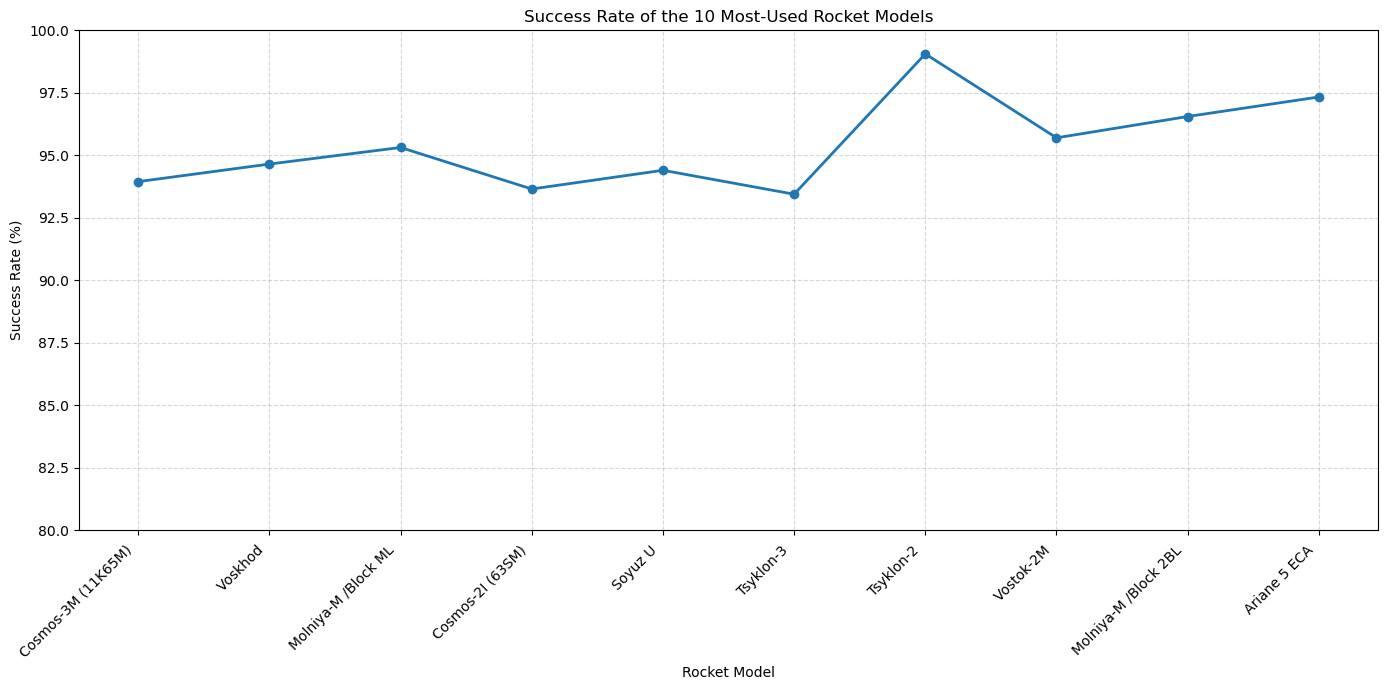

In [19]:
#Graph
plt.figure(figsize=(14, 7))

plt.plot(
    top10['Vehicle_Name'],
    top10['Success_Rate'],
    marker='o',
    linewidth=2
)

plt.title('Success Rate of the 10 Most-Used Rocket Models')
plt.xlabel('Rocket Model')
plt.ylabel('Success Rate (%)')

plt.xticks(rotation=45, ha='right')
plt.ylim(80, 100)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Inferences:
1. Tsyklon-2 has the highest success rate among the 15 most-used rocket models, with approximately 99.06%, showing very high reliability.
2. Vostok-2 has the lowest success rate, at approximately 84.44%, indicating comparatively lower reliability than the other frequently used models.
3. Most of the top 10 rocket models have success rates above 93%, showing that the frequently used rocket models in the dataset generally have a high level of launch reliability.

### Q8) "Which month recorded the highest number of rocket launches?"

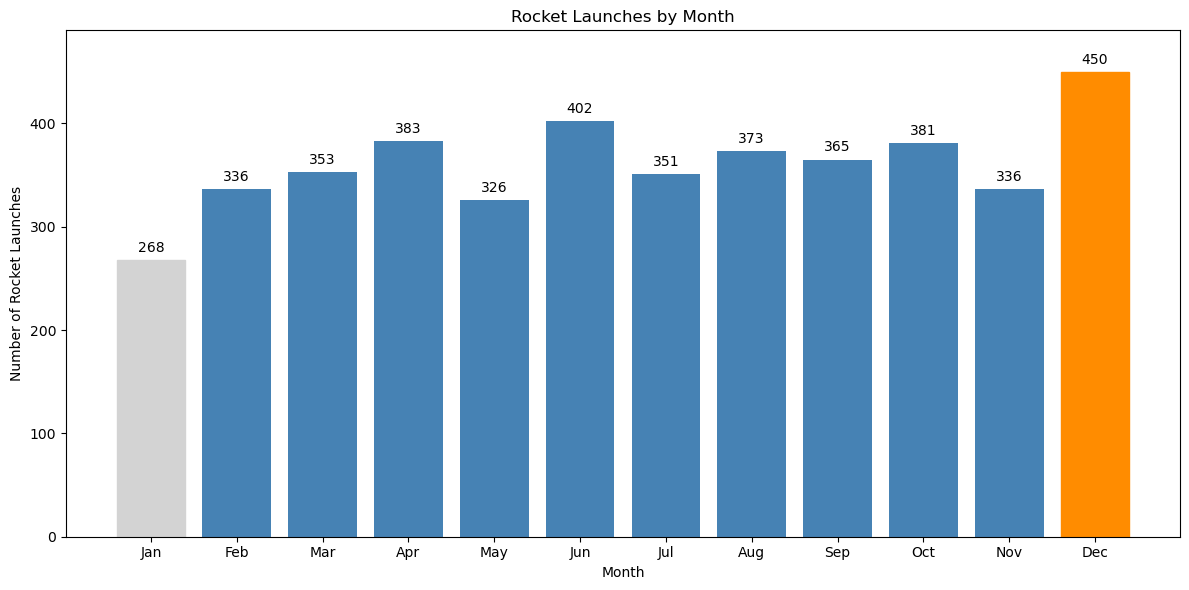

In [20]:
month_count = smd['Launch_Month'].value_counts()

# Reorder months Jan to Dec
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_count = month_count.reindex(month_order)

# Plot the bar chart
plt.figure(figsize=(12,6))

bars = plt.bar(month_count.index, month_count.values, color='steelblue')
# Highlight the highest bar (orange) and lowest bar (gray)
max_idx = month_count.values.argmax()
min_idx = month_count.values.argmin()
bars[max_idx].set_color('darkorange')
bars[min_idx].set_color('lightgray')

# Write the number on top of every bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height),
              ha='center', va='bottom', fontsize=10)

plt.xlabel('Month')
plt.ylabel('Number of Rocket Launches')
plt.title('Rocket Launches by Month')
plt.ylim(0, month_count.max() + 40)   # extra space so labels don't get cut off
plt.tight_layout()
plt.show()

This graph shows the number of rocket launches in different months. 

**infernce**

1.December had the highest number of launches, with around 450 launches.  
2.whereas the  January had the lowest, with around 270 launches.  
3.We can also see that June is another high-launch month, with 402 launches, followed by April and October.

but we can say that December appears to be the most active month for rocket launches, while January is the least active month..Overall, we can see that rocket launches were not the same in every month.


Why December has more launches:  

At the end of the year, space companies want to finish their yearly plans. So they try to complete extra launches before the year ends.  
Many government space agencies get money (budget) for the year, and they need to use it before the year finishes. So they launch more rockets in December  

Why January has fewer launches:  

January is the start of a new year. Companies are still planning and preparing for new missions, so fewer launches happen.  
After holidays and New Year celebrations, work slowly starts again. So there is a small delay.  

### Q9). How has the average mission price changed over time?

### Problem Statement: Has the average cost of a space mission increased or decreased as decades passed?

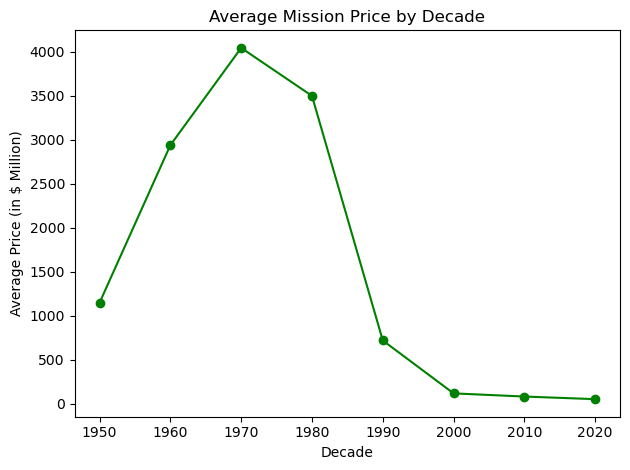

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the average price of missions in each decade
avg_price_by_decade = smd.groupby('Decade')['Price'].mean()

# Plot a line chart to show the trend
avg_price_by_decade.plot(kind='line', marker='o', color='green')
plt.title('Average Mission Price by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Price (in $ Million)')
plt.tight_layout()
plt.show()

"This line chart shows how the average price of a space mission has changed from the 1950s to today.  
Each dot on the line is one decade, and it shows the average cost of missions in that time period, in millions of dollars.  
**inference**  
1.In the 1950s, missions cost around 1,150 million dollars on average.as we move toward the 1960 to 1970
Average price peaked in the 1970s at about 4,043 million dollars per mission.  
2.Prices dropped sharply after that, falling to just 84 million dollars by the 2010s   
3.Today's missions cost around 54 million dollars on average nearly 99% cheaper than the 1970s peak.  
4.This shows space travel has become dramatically more affordable over 70 years.   

So overall, this graph tells us that space missions used to be extremely expensive, but over the decades, thanks to better technology and more companies entering the space industry, launching a mission has become far more affordable."  

